In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense
plt.style.use("seaborn-v0_8")

In [25]:
def load_coffee_data():
    """ Creates a coffee roasting data set.
        roasting duration: 12-15 minutes is best
        temperature range: 175-260C is best
    """
    rng = np.random.default_rng(2)
    X = rng.random(400).reshape(-1,2)
    X[:,1] = X[:,1] * 4 + 11.5          # 12-15 min is best
    X[:,0] = X[:,0] * (285-150) + 150  # 350-500 F (175-260 C) is best
    Y = np.zeros(len(X))
    
    i=0
    for t,d in X:
        y = -3/(260-175)*t + 21
        if (t > 175 and t < 260 and d > 12 and d < 15 and d<=y ):
            Y[i] = 1
        else:
            Y[i] = 0
        i += 1

    return X, Y.reshape(-1,1)

X, Y = load_coffee_data()

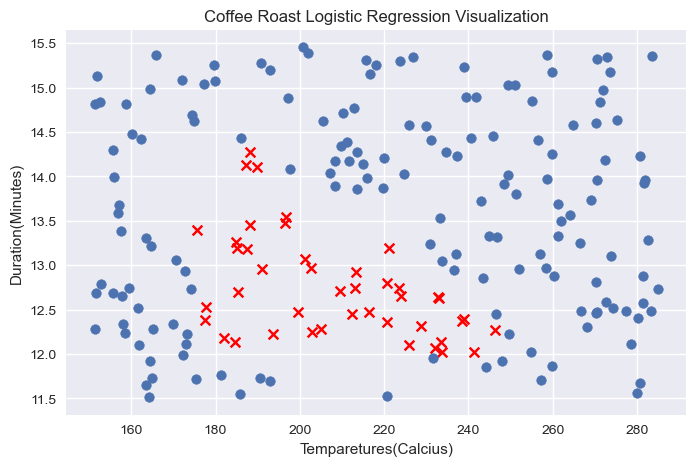

In [26]:
fig, ax = plt.subplots(1,1,figsize=(8,5))
pos = (Y==1).reshape(-1)
neg = (Y==0).reshape(-1)
ax.scatter(X[pos,0],X[pos,1],marker="x",c="r",label="y=1")
ax.scatter(X[neg,0],X[neg,1],marker="o",label="y=0")
ax.set_title("Coffee Roast Logistic Regression Visualization")
ax.set_xlabel("Temparetures(Calcius)")
ax.set_ylabel("Duration(Minutes)")
plt.show()

In [34]:
print(f"X.shape={X.shape}")
print(f"Y.shape={Y.shape}")
X

X.shape=(200, 2)
Y.shape=(200, 1)


array([[185.31763812,  12.69396457],
       [259.92047498,  11.86766377],
       [231.01357101,  14.41424211],
       [175.3666449 ,  11.72058651],
       [187.12086467,  14.12973206],
       [225.90586448,  12.10024905],
       [208.40515676,  14.17718919],
       [207.07593089,  14.0327376 ],
       [280.60385359,  14.23225929],
       [202.86935247,  12.24901028],
       [196.70468985,  13.54426389],
       [270.31327028,  14.60225577],
       [192.94979108,  15.19686759],
       [213.57283453,  14.27503537],
       [164.47298664,  11.91817423],
       [177.25750542,  15.03779869],
       [241.7745473 ,  14.89694529],
       [236.99889634,  13.12616959],
       [219.73805621,  13.87377407],
       [266.38592796,  13.25274466],
       [270.45241485,  13.95486775],
       [261.96307698,  13.49222422],
       [243.4899478 ,  12.8561015 ],
       [220.58184803,  12.36489356],
       [163.59498627,  11.65441652],
       [244.76317931,  13.32572248],
       [271.19410986,  14.84073282],
 

In [36]:
from tensorflow.keras.layers import Normalization
norm_1 = Normalization(axis=-1)
norm_1.adapt(X)
X_norm = norm_1(X)
X_norm

<tf.Tensor: shape=(200, 2), dtype=float32, numpy=
array([[-0.8345548 , -0.6528792 ],
       [ 1.0323056 , -1.3851453 ],
       [ 0.3089395 ,  0.8716251 ],
       [-1.0835686 , -1.5154841 ],
       [-0.7894309 ,  0.6194935 ],
       [ 0.18112455, -1.1790283 ],
       [-0.2568132 ,  0.6615495 ],
       [-0.29007566,  0.5335373 ],
       [ 1.5498862 ,  0.7103532 ],
       [-0.39534092, -1.047197  ],
       [-0.54960525,  0.1006532 ],
       [ 1.2923747 ,  1.0382426 ],
       [-0.64356774,  1.5651861 ],
       [-0.12749726,  0.7482604 ],
       [-1.356171  , -1.340383  ],
       [-1.0362515 ,  1.4242196 ],
       [ 0.5782223 ,  1.2993953 ],
       [ 0.45871648, -0.26986104],
       [ 0.0267812 ,  0.3926646 ],
       [ 1.194097  , -0.15769024],
       [ 1.2958571 ,  0.46452886],
       [ 1.0834197 ,  0.05453626],
       [ 0.6211483 , -0.5091947 ],
       [ 0.04789633, -0.94450104],
       [-1.3781422 , -1.5741245 ],
       [ 0.6530098 , -0.09301733],
       [ 1.3144174 ,  1.24958   ],
     

In [37]:
X_train = np.tile(X_norm, (1000,1))
Y_train = np.tile(Y, (1000,1))

In [38]:
X_train.shape

(200000, 2)

In [ ]:
tf.random.set_seed(1234)
model = Sequential([
    Input((2,)),
    Dense(3, activation="sigmoid", name="layer1"),
    Dense(1, activation="sigmoid", name="layer2")
])

from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import BinaryCrossentropy

model.compile(optimizer=Adam(learning_rate=0.01), loss=BinaryCrossentropy(from_logits=True), metrics=["accuracy"])

In [44]:
model.fit(X_train,Y_train,epochs=10)

Epoch 1/10
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 5s 668us/step - accuracy: 0.9094 - loss: 0.1857
Epoch 2/10
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 4s 667us/step - accuracy: 0.9488 - loss: 0.1197
Epoch 3/10
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 4s 652us/step - accuracy: 0.9836 - loss: 0.0493
Epoch 4/10
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 4s 666us/step - accuracy: 0.9989 - loss: 0.0178
Epoch 5/10
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 4s 637us/step - accuracy: 0.9997 - loss: 0.0117
Epoch 6/10
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 4s 641us/step - accuracy: 1.0000 - loss: 0.0083
Epoch 7/10
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 4s 646us/step - accuracy: 1.0000 - loss: 0.0061
Epoch 8/10
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 4s 635us/step - accuracy: 1.0000 - loss: 0.0044
Epoch 9/10
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 4s 638us/step - accuracy: 1.0000 - loss: 0.0032
Epoch 10/10
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 4s 656us/step - accuracy: 1.0000 - loss: 0.0024


In [54]:
X_test = np.array([[200.0, 17.0],
               [200.0, 13.9]])
X_test_norm = norm_1(X_test)
prediction = model.predict(X_test_norm)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step


In [55]:
predict = (prediction >= 0.5).astype(int)

In [56]:
predict

array([[0],
       [1]])

In [59]:
W1,b1 = model.get_layer("layer1").get_weights()

In [60]:
print(W1)
print(b1)

[[-7.1973465e-03  1.2802706e+01  1.4451707e+01]
 [-8.9777489e+00  2.7975029e-01  1.2093116e+01]]
[-11.241915  13.417015   1.811144]


In [61]:
model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ layer1 (Dense)                  │ (None, 3)              │             9 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │             4 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 41 (168.00 B)

 Trainable params: 13 (52.00 B)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 28 (116.00 B)